In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\JH\anaconda3\python.exe
3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [2]:
import numpy
import pandas
import sklearn
import matplotlib
import seaborn

print("NumPy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)

NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../orders_dataset.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (6000, 13)

Columns:
['order_id', 'product_category', 'price_inr', 'discount_pct', 'payment_method', 'customer_tenure_days', 'num_previous_orders', 'num_previous_returns', 'delivery_distance_km', 'delivery_days', 'is_weekend_order', 'rating_given', 'returned']


In [4]:
df.head(10)

,order_id,product_category,price_inr,discount_pct,payment_method,customer_tenure_days,num_previous_orders,num_previous_returns,delivery_distance_km,delivery_days,is_weekend_order,rating_given,returned
0,1,Footwear,2572.0,23.8,Prepaid_Card,17,3,0,604.6,1,0,2.0,0
1,2,Electronics,16689.0,6.7,COD,104,3,0,166.4,9,0,2.0,0
2,3,Footwear,800.0,51.3,Prepaid_Card,103,3,0,418.8,8,0,3.0,0
3,4,Home,7930.0,49.7,COD,1479,33,4,143.1,5,0,3.0,1
4,5,Apparel,715.0,0.0,COD,95,0,0,335.5,3,1,2.0,0
5,6,Beauty,750.0,24.7,Prepaid_Card,102,2,0,126.1,3,0,4.0,0
6,7,Footwear,1444.0,32.6,Prepaid_Card,14,1,0,355.1,5,1,3.0,0
7,8,Footwear,4132.0,28.6,Prepaid_UPI,459,11,1,191.3,8,0,4.0,0
8,9,Apparel,1775.0,44.7,Prepaid_UPI,656,16,0,169.9,10,1,1.0,1
9,10,Electronics,21231.0,41.6,Prepaid_UPI,231,8,1,194.1,4,0,3.0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              6000 non-null   int64  
 1   product_category      6000 non-null   object 
 2   price_inr             6000 non-null   float64
 3   discount_pct          6000 non-null   float64
 4   payment_method        6000 non-null   object 
 5   customer_tenure_days  6000 non-null   int64  
 6   num_previous_orders   6000 non-null   int64  
 7   num_previous_returns  6000 non-null   int64  
 8   delivery_distance_km  6000 non-null   float64
 9   delivery_days         6000 non-null   int64  
 10  is_weekend_order      6000 non-null   int64  
 11  rating_given          5217 non-null   float64
 12  returned              6000 non-null   int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 609.5+ KB


In [6]:
df.isnull().sum()

order_id                  0
product_category          0
price_inr                 0
discount_pct              0
payment_method            0
customer_tenure_days      0
num_previous_orders       0
num_previous_returns      0
delivery_distance_km      0
delivery_days             0
is_weekend_order          0
rating_given            783
returned                  0
dtype: int64

In [7]:
return_rate = df["returned"].mean()

print(f"Overall return rate: {return_rate:.4%}")

Overall return rate: 22.7500%


In [8]:
missing_rating_pct = df["rating_given"].isna().mean()

print(f"Missing rating percentage: {missing_rating_pct:.4%}")

Missing rating percentage: 13.0500%


In [9]:
category_return_rate = (
    df.groupby("product_category")["returned"]
      .mean()
      .sort_values(ascending=False)
      .mul(100)
)

category_return_rate

product_category
Apparel        26.427489
Footwear       25.957049
Beauty         20.034542
Home           19.146919
Electronics    18.693009
Name: returned, dtype: float64

In [10]:
category_return_rate.round(2)

product_category
Apparel        26.43
Footwear       25.96
Beauty         20.03
Home           19.15
Electronics    18.69
Name: returned, dtype: float64

In [11]:
payment_return_rate = (
    df.groupby("payment_method")["returned"]
      .mean()
      .sort_values(ascending=False)
      .mul(100)
)

payment_return_rate.round(2)

payment_method
COD             30.75
Wallet          17.85
Prepaid_UPI     16.92
Prepaid_Card    16.82
Name: returned, dtype: float64

In [12]:
df["is_cod"] = df["payment_method"].eq("COD")

missing_rating_by_cod = (
    df.groupby("is_cod")["rating_given"]
      .apply(lambda x: x.isna().mean() * 100)
)

missing_rating_by_cod

is_cod
False     6.058874
True     22.830868
Name: rating_given, dtype: float64

In [13]:
missing_rating_by_payment = (
    df.assign(
        payment_group=df["payment_method"].eq("COD")
                       .map({True: "COD", False: "Non-COD"})
    )
    .groupby("payment_group")["rating_given"]
    .apply(lambda x: x.isna().mean() * 100)
)

missing_rating_by_payment.round(2)

payment_group
COD        22.83
Non-COD     6.06
Name: rating_given, dtype: float64

In [14]:
cod_missing = missing_rating_by_payment["COD"]
non_cod_missing = missing_rating_by_payment["Non-COD"]

gap = cod_missing - non_cod_missing

print(f"COD missing-rating rate: {cod_missing:.2f}%")
print(f"Non-COD missing-rating rate: {non_cod_missing:.2f}%")
print(f"Gap: {gap:.2f} percentage points")

COD missing-rating rate: 22.83%
Non-COD missing-rating rate: 6.06%
Gap: 16.77 percentage points


In [15]:
df.describe()

,order_id,price_inr,discount_pct,customer_tenure_days,num_previous_orders,num_previous_returns,delivery_distance_km,delivery_days,is_weekend_order,rating_given,returned
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,5217.000000,6000.000000
mean,3000.500000,6874.652833,22.952233,381.398000,8.574500,1.187000,271.033733,4.557667,0.503000,2.981982,0.227500
std,1732.195139,10646.816148,14.105251,383.358353,8.685449,1.767452,156.965344,2.104696,0.500033,1.398284,0.419253
min,1.000000,153.000000,0.000000,1.000000,0.000000,0.000000,5.300000,1.000000,0.000000,1.000000,0.000000
25%,1500.750000,1241.750000,12.300000,108.000000,2.000000,0.000000,156.600000,3.000000,0.000000,2.000000,0.000000
50%,3000.500000,2089.000000,22.600000,258.000000,6.000000,1.000000,238.650000,4.000000,1.000000,3.000000,0.000000
75%,4500.250000,5749.500000,32.600000,535.000000,12.000000,2.000000,353.700000,6.000000,1.000000,4.000000,0.000000
max,6000.000000,44950.000000,75.000000,2500.000000,59.000000,19.000000,1086.700000,12.000000,1.000000,5.000000,1.000000


## Business Findings

### Overall Return Rate

The overall return rate is **22.75%**, which falls within the expected 18–27% range specified for the dataset.

### Return Rate by Product Category

Apparel has the highest return rate at **26.43%**, followed closely by Footwear at **25.96%**. Beauty and Home have moderate return rates, while Electronics has the lowest return rate at **18.69%**.

This indicates that Apparel and Footwear are the categories with the greatest return-risk exposure in the generated dataset.

### Return Rate by Payment Method

COD has the highest return rate at **30.75%**, substantially higher than Wallet (**17.85%**), Prepaid UPI (**16.92%**), and Prepaid Card (**16.82%**).

This suggests a strong association between COD payment and order returns in the dataset.

### Missing Rating Analysis

Overall, **13.05%** of `rating_given` values are missing.

Missing ratings occur at a rate of **22.83% for COD orders**, compared with **6.06% for non-COD orders**, giving a gap of **16.77 percentage points**.

Because the probability of a rating being missing depends on the observed `payment_method` variable, the missingness pattern is characterized as **Missing At Random (MAR)** rather than Missing Completely At Random (MCAR).

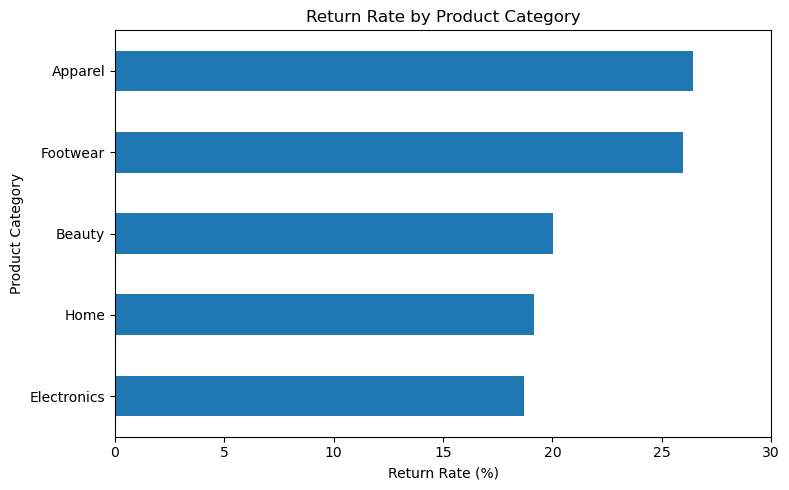

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

category_return_rate.sort_values().plot(kind="barh")

plt.xlabel("Return Rate (%)")
plt.ylabel("Product Category")
plt.title("Return Rate by Product Category")
plt.xlim(0, 30)

plt.tight_layout()
plt.show()

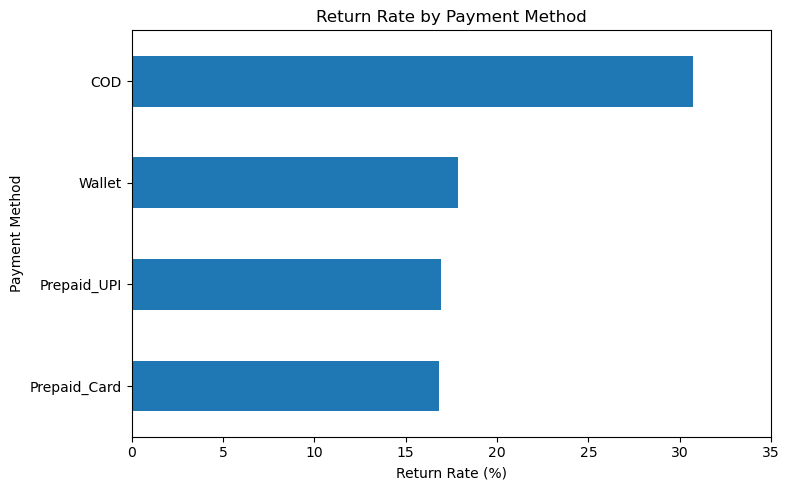

In [17]:
plt.figure(figsize=(8, 5))

payment_return_rate.sort_values().plot(kind="barh")

plt.xlabel("Return Rate (%)")
plt.ylabel("Payment Method")
plt.title("Return Rate by Payment Method")
plt.xlim(0, 35)

plt.tight_layout()
plt.show()

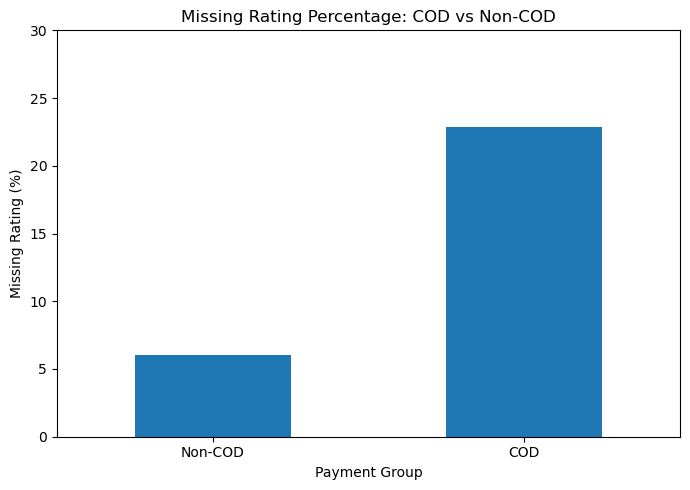

In [18]:
plt.figure(figsize=(7, 5))

missing_rating_by_payment.sort_values().plot(kind="bar")

plt.xlabel("Payment Group")
plt.ylabel("Missing Rating (%)")
plt.title("Missing Rating Percentage: COD vs Non-COD")
plt.xticks(rotation=0)
plt.ylim(0, 30)

plt.tight_layout()
plt.show()

### Visualization Insights

- **Product category:** Apparel and Footwear show the highest return rates, suggesting greater return-risk exposure for these categories.
- **Payment method:** COD has a substantially higher return rate (**30.75%**) than prepaid payment methods.
- **Rating missingness:** Missing ratings are much more frequent for COD orders (**22.83%**) than non-COD orders (**6.06%**), a difference of **16.77 percentage points**.
- The observed relationship between missingness and the observed `payment_method` variable supports characterizing the missingness mechanism as **MAR rather than MCAR**.